In [14]:
#Importovanje potrebnih biblioteka
from tensorflow import keras 
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from datetime import datetime

In [15]:
# Ucitavanje .csv fajla
df = pd.read_csv('nis-air-quality.csv', delimiter=",")
Nis = pd.DataFrame(df)
print(Nis)
Nis.dtypes

           date  pm25 pm10 o3  no2 so2   co
0      2026/1/1   142            9   3    6
1      2026/1/2    87           11   2    6
2      2026/1/3    88           10   2    6
3      2026/1/4    92           16   3   10
4      2026/1/5   132            9   2    7
...         ...   ...  ... ..  ...  ..  ...
3565  2016/2/25                 11       11
3566  2016/2/26                  9        6
3567  2016/2/27                 11        8
3568  2016/2/28                  9        8
3569  2016/2/29                 11        5

[3570 rows x 7 columns]


date    object
pm25    object
pm10    object
o3      object
no2     object
so2     object
co      object
dtype: object

In [16]:
#Promena datatype u odgovarajuci format
Nis[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']] = Nis[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']].astype("string")
Nis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3570 entries, 0 to 3569
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    3570 non-null   object
 1   pm25    3570 non-null   string
 2   pm10    3570 non-null   string
 3   o3      3570 non-null   string
 4   no2     3570 non-null   string
 5   so2     3570 non-null   string
 6   co      3570 non-null   string
dtypes: object(1), string(6)
memory usage: 195.4+ KB


In [17]:
#Promena datatype u odgovarajuci format
Nis['pm25'] = pd.to_numeric(Nis['pm25'], errors='coerce')
Nis['pm10'] = pd.to_numeric(Nis['pm10'], errors='coerce')
Nis['o3'] = pd.to_numeric(Nis['o3'], errors='coerce')
Nis['no2'] = pd.to_numeric(Nis['no2'], errors='coerce')
Nis['so2'] = pd.to_numeric(Nis['so2'], errors='coerce')
Nis['co'] = pd.to_numeric(Nis['co'], errors='coerce')
Nis.info()
Nis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3570 entries, 0 to 3569
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    3570 non-null   object
 1   pm25    3218 non-null   Int64 
 2   pm10    3174 non-null   Int64 
 3   o3      12 non-null     Int64 
 4   no2     3485 non-null   Int64 
 5   so2     2816 non-null   Int64 
 6   co      1906 non-null   Int64 
dtypes: Int64(6), object(1)
memory usage: 216.3+ KB


,date,pm25,pm10,o3,no2,so2,co
0,2026/1/1,142,<NA>,<NA>,9,3,6
1,2026/1/2,87,<NA>,<NA>,11,2,6
2,2026/1/3,88,<NA>,<NA>,10,2,6
3,2026/1/4,92,<NA>,<NA>,16,3,10
4,2026/1/5,132,<NA>,<NA>,9,2,7
...,...,...,...,...,...,...,...
3565,2016/2/25,<NA>,<NA>,<NA>,11,<NA>,11
3566,2016/2/26,<NA>,<NA>,<NA>,9,<NA>,6
3567,2016/2/27,<NA>,<NA>,<NA>,11,<NA>,8
3568,2016/2/28,<NA>,<NA>,<NA>,9,<NA>,8


In [18]:
#Postavljanje date kolone na mesto index
Nis.index = pd.to_datetime(Nis["date"])
Nis.sort_index(inplace=True)
Nis.drop(columns=["date","o3"], inplace=True)
Nis

,pm25,pm10,no2,so2,co
date,,,,,
2016-01-04,<NA>,<NA>,11,<NA>,10
2016-01-05,<NA>,<NA>,21,<NA>,26
2016-01-06,<NA>,<NA>,16,<NA>,19
2016-01-07,<NA>,<NA>,12,<NA>,15
2016-01-08,<NA>,<NA>,19,<NA>,28
...,...,...,...,...,...
2026-01-16,129,<NA>,6,2,2
2026-01-17,80,<NA>,5,2,<NA>
2026-01-18,73,<NA>,12,2,2


In [19]:
#popunjavanje nedostajucih vrednosti
Nis.ffill(inplace = True)
Nis.bfill(inplace = True)
Nis.head(20)

,pm25,pm10,no2,so2,co
date,,,,,
2016-01-04,128,63,11,10,10
2016-01-05,128,63,21,10,26
2016-01-06,128,63,16,10,19
2016-01-07,128,63,12,10,15
2016-01-08,128,63,19,10,28
2016-01-09,128,63,21,10,37
2016-01-10,128,63,15,10,46
2016-01-11,128,63,11,10,22
2016-01-12,128,63,17,10,12


In [20]:
# Kreiranje AQI kolone kao indeks zagadjenosti vazduha
Nis['AQI'] = Nis[['pm25','pm10','no2','so2','co']].max(axis=1)
Nis


,pm25,pm10,no2,so2,co,AQI
date,,,,,,
2016-01-04,128,63,11,10,10,128
2016-01-05,128,63,21,10,26,128
2016-01-06,128,63,16,10,19,128
2016-01-07,128,63,12,10,15,128
2016-01-08,128,63,19,10,28,128
...,...,...,...,...,...,...
2026-01-16,129,88,6,2,2,129
2026-01-17,80,88,5,2,2,88
2026-01-18,73,88,12,2,2,88


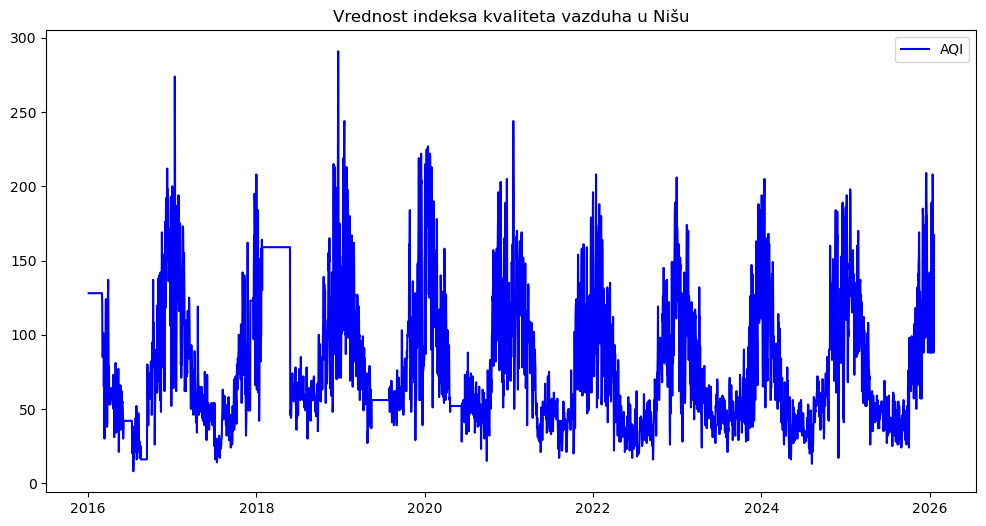

In [21]:
#Grafik za prikaz AQI
plt.figure(figsize=(12,6))
plt.plot(Nis.index, Nis['AQI'], label = "AQI", color = "blue")
plt.title("Vrednost indeksa kvaliteta vazduha u Nišu")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Matrica korelacije')

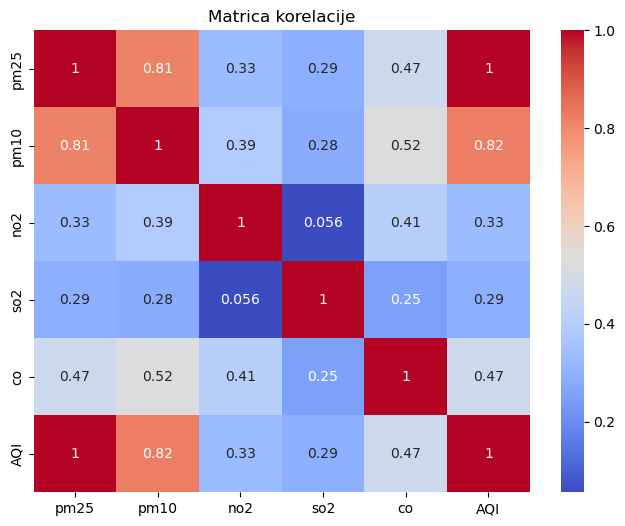

In [22]:
#Matrica korelacije
plt.figure(figsize=(8,6))
sns.heatmap(Nis.corr(), annot=True, cmap="coolwarm")
plt.title("Matrica korelacije")

In [23]:
#Kreiranje trening data
AQI_val = Nis.filter(["AQI"])
dataset = AQI_val.values
training_data_len = int(np.ceil(len(dataset)*0.9875))

In [24]:
# Standradizacija vrednosti za unos u LSTM model
scaler= StandardScaler()
scaled_data= scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len]

X_train, y_train = [], []

In [25]:
# Kreiranje prozora(window) za posmatranje vrednosti unutar modela
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [26]:
# Kreiranje modela
model = keras.models.Sequential()
# Kreiranje 1. nivoa
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))
# Kreiranje 2. nivoa
model.add(keras.layers.LSTM(64, return_sequences=False))
# Kreiranje 3. nivoa
model.add(keras.layers.Dense(128, activation="relu"))
# Kreiranje 4. nivoa
model.add(keras.layers.Dropout(0.5))
# Kreiranje konacnog nivoa
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

E:\anaconda\envs\python_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#pokretanje modela
training = model.fit(X_train, y_train, epochs=20, batch_size=32)

test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))


Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.4710 - root_mean_squared_error: 0.6482
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4212 - root_mean_squared_error: 0.5946
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3889 - root_mean_squared_error: 0.5458
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3631 - root_mean_squared_error: 0.5142
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3500 - root_mean_squared_error: 0.4999
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3501 - root_mean_squared_error: 0.4975
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3434 - root_mean_squared_error: 0.4942
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3436 - root_mean_squared_error: 0.4955
Epoch 9/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3421 - root_mean_squared_error: 0.4932
Epoch 10/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3410 - root_mean_s

In [28]:
# Vrsenje predvidjana vrednosti
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step


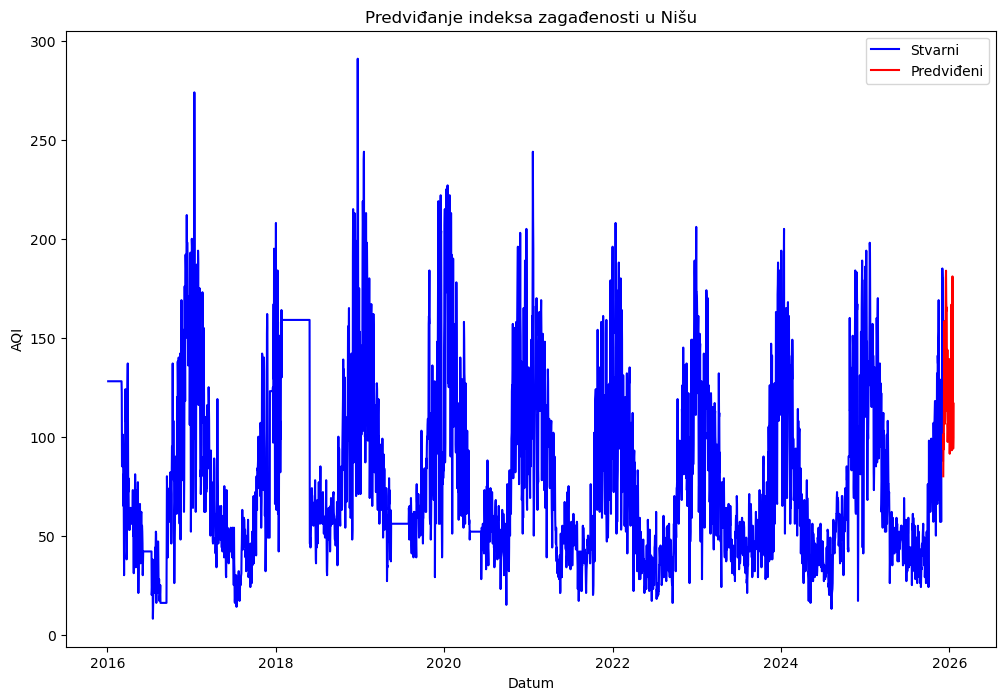

In [30]:
# Prikaz rezultata na grafikonu
train = Nis[:training_data_len]
test =  Nis[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(12,8))
plt.plot(train.index, train['AQI'], label="Stvarni", color='blue')
plt.plot(test.index, test['Predictions'], label="Predviđeni", color='red')
plt.title("Predviđanje indeksa zagađenosti u Nišu")
plt.xlabel("Datum")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [31]:
# Prikaz konkretnih predvidjenih vrednosti
test['Predictions']


date
2025-12-06     79.972298
2025-12-07    101.363663
2025-12-08     93.571503
2025-12-09    111.409355
2025-12-10    157.177551
2025-12-11    158.332260
2025-12-12    146.808167
2025-12-13    106.507744
2025-12-14    108.889992
2025-12-15    118.950478
2025-12-16    157.096680
2025-12-17    178.926773
2025-12-18    183.877762
2025-12-19    168.449829
2025-12-20    163.645981
2025-12-21    165.278473
2025-12-22    113.018829
2025-12-23    114.323486
2025-12-24    143.878616
2025-12-25     97.348297
2025-12-26    106.679070
2025-12-27    102.160278
2025-12-28    116.733658
2025-12-31    101.950661
2026-01-01    103.130760
2026-01-02    139.195831
2026-01-03     91.368507
2026-01-04     99.919525
2026-01-05     97.762573
2026-01-06    129.201645
2026-01-07     95.680511
2026-01-08     94.666817
2026-01-09    104.752579
2026-01-10    166.720825
2026-01-11    106.214088
2026-01-12     93.136185
2026-01-13    111.809853
2026-01-14    152.906967
2026-01-15    181.004089
2026-01-16    153.88

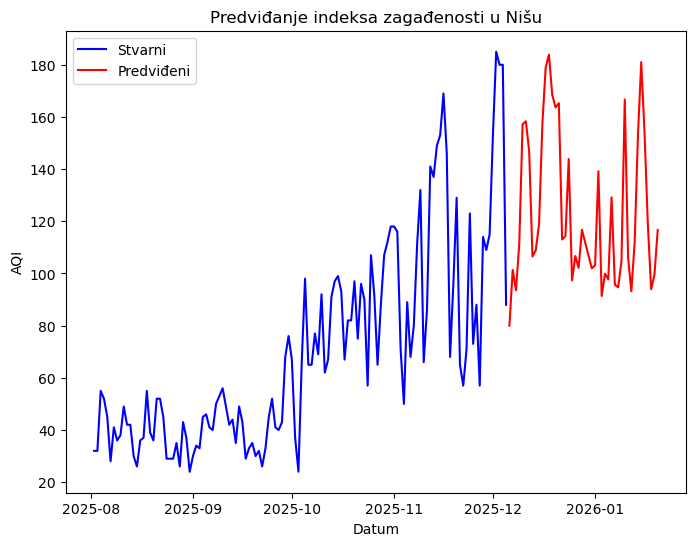

In [34]:
# Kreiranje manjeg i vidljivijeg grafikona
train = Nis.loc[(Nis.index > datetime(2025,8,1)) & (Nis.index < datetime(2025,12,6))]
test =  Nis[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(8,6))
plt.plot(train.index, train['AQI'], label="Stvarni", color='blue')
plt.plot(test.index, test['Predictions'], label="Predviđeni", color='red')
plt.title("Predviđanje indeksa zagađenosti u Nišu")
plt.xlabel("Datum")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [35]:
Prognoza_Nis = pd.DataFrame(test['Predictions'])
Prognoza_Nis.to_csv('prognoza_nis.csv')

In [36]:
Prognoza_Nis['Predictions'] = Prognoza_Nis['Predictions'].round(0).astype(int)
Prognoza_Nis

,Predictions
date,
2025-12-06,80
2025-12-07,101
2025-12-08,94
2025-12-09,111
2025-12-10,157
2025-12-11,158
2025-12-12,147
2025-12-13,107
2025-12-14,109


In [37]:
Prognoza_Nis['Predictions'].mean()

np.float64(123.81818181818181)